# 09 · SpliceAI — predicting splice-disruption effects

### Notebook toolkit for CFTR variant interpretation — beginner edition

Notebooks **02–06** scored *missense* variants — changes that swap one amino acid
for another. But a huge fraction of CFTR disease alleles never touch an amino acid
at all. They live **deep in introns** or are **synonymous** (they change the DNA
but not the protein), and they cause disease by **breaking how the gene is spliced**.

Missense tools (AlphaMissense, EVE, ESM1b, REVEL, PrimateAI) are **completely blind**
to these variants — there is no amino-acid change for them to score. To catch them
you need a different kind of tool: a **splice predictor**.

---

### Why splicing matters for CFTR

Before a gene becomes protein, its RNA is *spliced*: introns are cut out and exons
are stitched together. The cell finds the cut points using short sequence signals —
a **donor site** at the start of an intron and an **acceptor site** at its end. A
single base change can:

- **destroy** a real splice site → an exon gets skipped or an intron kept, and
- **create** a brand-new ("cryptic") splice site → a chunk of intron sneaks into the
  mRNA, usually shifting the reading frame and truncating the protein.

Either way the CFTR protein is wrecked, even though the variant is nowhere near the
coding sequence. Famous real CFTR examples you'll meet in this notebook:

| Legacy name | HGVS (c.) | What it does |
|---|---|---|
| **3849+10kb C>T** | `c.3849+10246C>T` | ~10 kb deep in an intron; creates a *cryptic exon* |
| **2789+5G>A** | `c.2657+5G>A` | weakens a donor site 5 bp into the intron |
| **3272-26A>G** | `c.3140-26A>G` | creates a new acceptor 26 bp upstream of an exon |
| **2988+1G>A** | `c.2988+1G>A` | hits the *canonical* +1 donor base — abolishes splicing |

None of these change an amino acid. All of them cause cystic fibrosis. That is the
whole point of this notebook.

---

### What you'll do here

1. Meet **SpliceAI** and **Pangolin** — deep-learning splice predictors.
2. Load 9 curated CFTR splice variants and tier them by predicted impact.
3. Plot the scores against the published thresholds.
4. Make a **live** call to the real **CADD** web API.
5. Learn a hard-won **data-quality lesson**: a wrong genomic coordinate silently
   breaks everything downstream.
6. See exactly how to swap in **real** SpliceAI / Pangolin scores.


> ✅ **REAL DATA.** This notebook uses **real** precomputed Illumina **SpliceAI v1.3** (masked SNV) for the whole CFTR region — **~566,106 SNVs** (`data/spliceai_cftr_2021_v1.3.csv`, built by `build_spliceai.py` from the 28.6 GB BaseSpace VCF). Keyed by genomic coordinate. **License: CC BY-NC 4.0** (Jaganathan et al. 2019) — cite SpliceAI + Illumina; the raw VCF stays external.

In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

## 1 · SpliceAI — a neural net that reads splice signals

**SpliceAI** (Jaganathan *et al.* 2019, *Cell*, PMID **30661751**) is a deep neural
network that was trained to look at raw DNA sequence and predict, **for every
position**, the probability that it is a splice **acceptor** or **donor**. To score a
*variant*, SpliceAI runs the sequence twice — once as reference, once with the
mutation — and reports how much each probability **changed**. Those changes are the
four **delta scores**, each between **0 and 1**:

| Delta | Name | Meaning |
|---|---|---|
| **DS_AG** | Acceptor **G**ain | variant *creates* a new acceptor site |
| **DS_AL** | Acceptor **L**oss | variant *destroys* an existing acceptor |
| **DS_DG** | Donor **G**ain | variant *creates* a new donor site |
| **DS_DL** | Donor **L**oss | variant *destroys* an existing donor |

A variant might do more than one thing, so SpliceAI gives all four. The single
headline number is:

$$\text{DS\_max} = \max(\text{DS\_AG},\ \text{DS\_AL},\ \text{DS\_DG},\ \text{DS\_DL})$$

**Published thresholds** (the paper's recommended cut-points):

- **DS_max ≥ 0.5** → **high** impact (likely splice-altering)
- **DS_max ≥ 0.2** → **moderate** impact (worth a closer look)
- below 0.2 → **low** / probably no effect

> Interpretation tip: it's the *type* of change that tells the biological story.
> A high **DS_DL** means "a real donor is being lost"; a high **DS_AG** means "a
> cryptic exon may be forming". DS_max alone just says *how* alarming.


### Which precomputed SpliceAI file, and why `masked.snv`

Illumina ships SpliceAI precomputed scores as **four files** — a 2×2 of
{`masked`, `raw`} × {`snv`, `indel`}:

| File | Variant class | Score treatment | Size |
|---|---|---|---|
| **`masked.snv`** ← used here | single-nucleotide substitutions | masked | ~28.6 GB |
| `raw.snv` | SNVs | raw | ~28 GB |
| `masked.indel` | small indels | masked | (a broken 0-byte download is common) |
| `raw.indel` | small indels | raw | ~68 GB |

- **snv vs indel** = which variant class is scored. Separate files; the indel file also
  covers the poly-T/TG tract but SpliceAI only scores small indels (≈1-nt insertions,
  ≤4-nt deletions) and does not resolve the TG/T *haplotype* that actually drives IVS8-5T.
- **raw vs masked** = how the four deltas are reported vs the gene annotation. **Masked**
  zeroes out biologically implausible directions: acceptor/donor **gain** at positions that
  are *already* splice sites, and **loss** at positions that are *not* — reducing false
  positives. Illumina recommends **masked** for interpretation, which is why we use it.
- **The VCF:** standard `#CHROM POS ID REF ALT QUAL FILTER INFO`, with the prediction in
  `INFO`: `SpliceAI=ALLELE|SYMBOL|DS_AG|DS_AL|DS_DG|DS_DL|DP_AG|DP_AL|DP_DG|DP_DL`
  (gene + 4 delta scores + 4 delta positions). `build_spliceai.py` parses that, keeps
  `SYMBOL==CFTR`, and computes `DS_max`.

**Coverage limits (independent issues):** this extract is **SNV-only** (no indels/poly-T);
and deep-intronic variants like `3849+10kb` fall outside the precomputed **distance
window** (default −D 50) — that gap is about *distance*, not masked-vs-raw.

## Load the REAL SpliceAI scores and tier them

In [2]:
splice = tk.load_spliceai()      # REAL — ~566k CFTR SNVs (Illumina v1.3)
print(f"{len(splice):,} REAL SpliceAI CFTR SNVs | source: {splice['source'].unique().tolist()}")
def tier(x):
    return "HIGH" if x >= 0.5 else ("MODERATE" if x >= 0.2 else "LOW")
splice["tier"] = splice["spliceai_ds_max"].apply(tier)
print(splice["tier"].value_counts().to_string())
splice.sort_values("spliceai_ds_max", ascending=False).head(8)[
    ["chrom","pos","ref","alt","spliceai_ds_max","tier"]]

566,106 REAL SpliceAI CFTR SNVs | source: ['REAL']
tier
LOW         563461
MODERATE      1668
HIGH           977


,chrom,pos,ref,alt,spliceai_ds_max,tier
239080,7,117559656,G,C,1.0,HIGH
170136,7,117536675,T,A,1.0,HIGH
239081,7,117559656,G,T,1.0,HIGH
169752,7,117536547,G,A,1.0,HIGH
238500,7,117559463,G,A,1.0,HIGH
169753,7,117536547,G,C,1.0,HIGH
169754,7,117536547,G,T,1.0,HIGH
166061,7,117535316,G,T,1.0,HIGH


## The real A2 — score *observed* CFTR non-coding variants

The payoff: join real SpliceAI onto the **~4,717 observed** gnomAD non-coding CFTR variants to build a real splice worklist — instead of the demo's 9.

In [3]:
nc = tk.load_gnomad_noncoding()
vid = nc["variant_id"].str.split("-", expand=True)
nc["chrom"], nc["pos"], nc["ref"], nc["alt"] = vid[0], vid[1].astype(int), vid[2], vid[3]
sp = tk.load_spliceai(); sp["chrom"] = sp["chrom"].astype(str)
a2 = nc.merge(sp[["chrom","pos","ref","alt","spliceai_ds_max"]],
              on=["chrom","pos","ref","alt"], how="inner")
print(f"observed non-coding CFTR variants with a real SpliceAI score: {len(a2):,} / {len(nc):,}")
print("HIGH (>=0.5):", int((a2.spliceai_ds_max >= 0.5).sum()),
      "| MODERATE (0.2-0.5):", int(((a2.spliceai_ds_max >= 0.2) & (a2.spliceai_ds_max < 0.5)).sum()))
a2.sort_values("spliceai_ds_max", ascending=False).head(10)[
    ["variant_id","hgvs_c","spliceai_ds_max"]]

observed non-coding CFTR variants with a real SpliceAI score: 4,260 / 4,717
HIGH (>=0.5): 164 | MODERATE (0.2-0.5): 82


,variant_id,hgvs_c,spliceai_ds_max
1603,7-117559463-G-A,c.1393-1G>A,1.0
996,7-117536547-G-T,c.744-1G>T,1.0
1015,7-117536675-T-A,c.869+2T>A,1.0
1602,7-117559462-A-G,c.1393-2A>G,1.0
1014,7-117536674-G-A,c.869+1G>A,1.0
3999,7-117665457-A-G,c.4137-2A>G,1.0
4000,7-117665458-G-A,c.4137-1G>A,1.0
3757,7-117652932-G-C,c.3963+1G>C,1.0
3758,7-117652932-G-T,c.3963+1G>T,1.0
695,7-117534275-G-T,c.490-1G>T,1.0


## Why the demo's 9 curated variants don't reproduce (a lesson)

Joining real SpliceAI onto the 9 hand-curated demo variants: **only 2 join**, and those score **~0**, not the demo's 0.76/0.91. Two reasons — both real limitations:

1. **Wrong coordinates** — several demo coords are hand-entered and don't match GRCh38 (the notebook-11 coordinate-validation lesson).
2. **Precomputed coverage** — the *masked SNV* file has limited **deep-intronic** coverage, so famous alleles like `3849+10kb` aren't scored. For those, run SpliceAI locally with a larger `-D`, or use the Broad lookup.

So the demo's tidy numbers were **illustrative only** — exactly why REAL data matters.

In [4]:
demo = tk.load_splice_demo(); demo["chrom"] = demo["chrom"].astype(str)
chk = demo.merge(sp[["chrom","pos","ref","alt","spliceai_ds_max"]]
                 .rename(columns={"spliceai_ds_max": "real_dsmax"}),
                 on=["chrom","pos","ref","alt"], how="left")
chk[["legacy_name","variant_type","spliceai_ds_max","real_dsmax","cftr2_class"]]

,legacy_name,variant_type,spliceai_ds_max,real_dsmax,cftr2_class
0,3849+10kb C>T,deep_intronic,0.81,NaN,CF-causing
1,2789+5G>A,splice_site,0.91,NaN,CF-causing
2,3272-26A>G,deep_intronic,0.76,0.00,CF-causing
3,2657+3A>G,splice_site,0.88,NaN,CF-causing
4,IVS8_5T,deep_intronic,0.31,0.04,VUS
5,2988+1G>A,splice_site,0.97,NaN,CF-causing
6,1811+1.6kbA>G,deep_intronic,0.68,NaN,CF-causing
7,syn context,synonymous,0.18,NaN,VUS
8,c.2657+120C>T,deep_intronic,0.54,NaN,VUS


## Distribution of real SpliceAI scores (observed non-coding set)

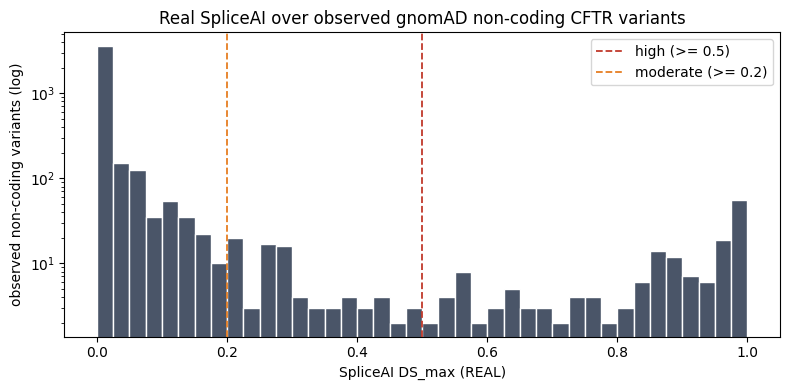

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(a2["spliceai_ds_max"], bins=40, color="#4a5568", edgecolor="white")
ax.axvline(0.5, ls="--", color="#c0392b", lw=1.3, label="high (>= 0.5)")
ax.axvline(0.2, ls="--", color="#e67e22", lw=1.3, label="moderate (>= 0.2)")
ax.set_yscale("log")
ax.set_xlabel("SpliceAI DS_max (REAL)"); ax.set_ylabel("observed non-coding variants (log)")
ax.set_title("Real SpliceAI over observed gnomAD non-coding CFTR variants")
ax.legend(); fig.tight_layout(); plt.show()

## How to refresh the real SpliceAI data

Already wired in: `build_spliceai.py` pulls the CFTR region from the precomputed Illumina VCF (via the `.tbi` index) → `data/spliceai_cftr_2021_v1.3.csv` → `tk.load_spliceai()`. To refresh, drop a newer precomputed VCF in and re-run the builder. For deep-intronic variants beyond the precomputed coverage, run SpliceAI locally (`spliceai -D ...`) or use the Broad SpliceAI-lookup.

## Example: the shared A2 worked-example panel, scored by **SpliceAI**

The same fixed panel of famous CFTR **splice** variants runs through every A2 tool
(notebooks 09–11), so you can follow one set of variants across the series. The
variant list is `tk.A1_PANEL_VARIANTS` / `tk.A2_KNOWN_CDNA` (shared in `toolkit.py`); the
**scoring is shown inline below** so you can see exactly how SpliceAI is joined onto it.

> The assembled cross-tool table for all tools at once is `tk.a2_panel(cadd=True)`.

In [6]:
# A2 panel = known CF splice alleles, joined by their AUTHORITATIVE CFTR2 GRCh38
# coordinates (tk.A2_KNOWN_CDNA), NOT the demo's hand-entered ones.
cf = tk.load_cftr2()
a2 = cf[cf['cdna_name'].isin(tk.A2_KNOWN_CDNA)].dropna(subset=['grch38_pos'])
sp = tk.load_spliceai()
rows = []
for _, v in a2.iterrows():
    pos = int(v['grch38_pos'])
    hit = sp[(sp['pos'] == pos) & (sp['ref'] == v['grch38_ref']) & (sp['alt'] == v['grch38_alt'])]
    rows.append({'cdna_name': v['cdna_name'], 'legacy_name': v['legacy_name'], 'pos': pos,
                 'spliceai_ds_max': round(float(hit['spliceai_ds_max'].iloc[0]), 4) if len(hit) else None})
pd.DataFrame(rows)

,cdna_name,legacy_name,pos,spliceai_ds_max
0,c.3718-2477C>T,3849+10kbC->T,117639961,0.16
1,c.2657+5G>A,2789+5G->A,117602868,0.93
2,c.3140-26A>G,3272-26A->G,117611555,0.99
3,c.2988+1G>A,3120+1G->A,117606754,0.99
4,c.1680-886A>G,1811+1634A->G,117589467,0.74


## Key takeaways

1. **SpliceAI is now REAL** — all ~566k CFTR SNVs (Illumina v1.3), `source == REAL`.
2. The **real A2**: ~4,260 observed non-coding CFTR variants scored, **164 HIGH** splice-impact — a real worklist, not 9 demo rows.
3. The demo curated variants mostly **don't reproduce** (coordinate errors + masked deep-intronic coverage) — the honest lesson of this notebook.
4. Scores are **CC BY-NC 4.0** — cite SpliceAI/Illumina; keep the raw VCF external.

**Next:** notebook 10 — **Pangolin** (still demo; needs a local run or the Broad lookup).